In [1]:
import yaml
import sys 
from loguru import logger
import pprint
import torch
import numpy as np
import os
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

#sys.path.append("../")
from pathlib import Path
# Go to project root (parent of notebooks/)
ROOT = Path.cwd().parents[0]

'''IJEPA_ROOT = ROOT / "submodules" / "ijepa"
VJEPA_ROOT = ROOT / "submodules" / "vjepa2"
'''
#sys.path.append(str(IJEPA_ROOT))

#from src.helper import init_model

sys.path.append(str(ROOT))
# Insert V-JEPA src FIRST
#sys.path.insert(0, str(VJEPA_ROOT))


from app.decoder.utils import init_video_model, load_checkpoint, load_pretrained

from src.datasets.data_manager import init_data
import yaml
from app.vjepa.transforms import GeoVideoTransformWithCrop
from src.datasets.geonpy_loader import make_geonpy_loader

/opt/conda/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
# -----------------------------
# 1. Load model + checkpoint
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

patch_size = 16
tubelet_size = 2
max_num_frames = 16
crop_size = 256
in_chans = 22
B = 10

encoder, decoder = init_video_model(
    device=device,
    patch_size=patch_size,
    max_num_frames=max_num_frames,
    tubelet_size=tubelet_size,
    model_name="vit_base",
    crop_size=crop_size,
    depth=6,
    num_heads=16,
    decoder_embed_dim=512,
    in_chans=in_chans,
    use_activation_checkpointing=False,
    use_sdpa=True,
    use_rope=True,
    c=1
)

target_encoder = encoder  # same architecture
target_encoder = target_encoder.to(device)
decoder = decoder.to(device)

# Load pretrained encoder weights
# Load pretrained target encoder checkpoint
ckpt = torch.load("../logs/pretrain/16.8.vitb.256px.16f/latest.pt", map_location=device, weights_only=True)

pretrained_dict = ckpt["target_encoder"]

# Strip both "module." and "backbone."
clean_state = {}
for k, v in pretrained_dict.items():
    k = k.replace("module.", "")
    k = k.replace("backbone.", "")
    clean_state[k] = v

msg = target_encoder.load_state_dict(clean_state, strict=True)
print("Target encoder loaded with msg:", msg)



# Load trained decoder checkpoint
ckpt = torch.load("../logs/decoder/16.8.vitb.256px.16f/latest.pt", map_location=device, weights_only=True)
decoder_state = ckpt["decoder"]
# Remove "module." prefix if present
decoder_state = {k.replace("module.", ""): v for k, v in decoder_state.items()}
msg = decoder.load_state_dict(decoder_state, strict=True)
print("decoder loaded with msg:", msg)

decoder.eval()
#target_encoder.eval()

# -----------------------------
# 2. Load a sample clip
# -----------------------------
# Apply same transform as training
transform = GeoVideoTransformWithCrop(
    ratio=[0.75, 1.35],
    scale=[0.3, 1.0],
    crop_size=crop_size,
    motion_shift=False,
)
video_collator = torch.utils.data.default_collate

root = os.path.abspath("../../../../Dataset_collection/Colorado_data/v_jepa_data/16f_v2 (no aspect)/normalized")
(val_dataset, val_loader, val_sampler) = make_geonpy_loader(
        root_path=["/home/jovyan/Sujet_speciale/Dataset_collection/Colorado_data/v_jepa_data/16f_v2 (no aspect)/normalized"],
        transform=transform,   # same transform or a deterministic one
        batch_size=B,
        collator=video_collator,
        pin_mem=False,
        num_workers=0,
        world_size=1,
        rank=0,
        persistent_workers=False,
        dataset_fpcs=[16],
        num_clips=1,
        decoding=True,
        training=False,
        only_flood=False,
        c=1
    )

[INFO    ][2026-04-29 00:35:55][root                ][init_video_model         ] VisionTransformer(
  (patch_embed): PatchEmbed3D(
    (proj): Conv3d(22, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): RoPEAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, 

# decoder visualization

In [3]:
sample = next(iter(val_loader))
clip = sample[0].to("cuda") # [B, C, T, H, W]
flood_label = sample[1].to("cuda")
# -----------------------------
# 3. Forward through encoder
# -----------------------------
with torch.no_grad():
    # Duplicate frames for tubelet_size=2 (same as training)
    c = clip.permute(0, 2, 1, 3, 4)          # [B, T, C, H, W]
    c = c.flatten(0, 1).unsqueeze(2)         # [B*T, C, 1, H, W]
    c = c.repeat(1, 1, 2, 1, 1)              # [B*T, C, 2, H, W]

    h = target_encoder(c)                    # [B*T, N, D]
    h = h.view(B, max_num_frames, -1, h.size(-1)).flatten(1, 2)  # [1, N_total, D]

# -----------------------------
# 4. Decode to flood mask
# -----------------------------
with torch.no_grad():
    pred = decoder(h)  # [B, 1, T, H, W]
# -----------------------------
# 5. Visualize
# -----------------------------

/opt/conda/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [4]:
for i in range(10):
    print(h[0, i].mean().item())

0.00011972834909101948
8.373335003852844e-05
0.00011235848069190979
0.00010870397090911865
8.397673809668049e-05
6.981070328038186e-05
7.516394543927163e-05
8.250772953033447e-05
8.033215999603271e-05
9.371961641591042e-05


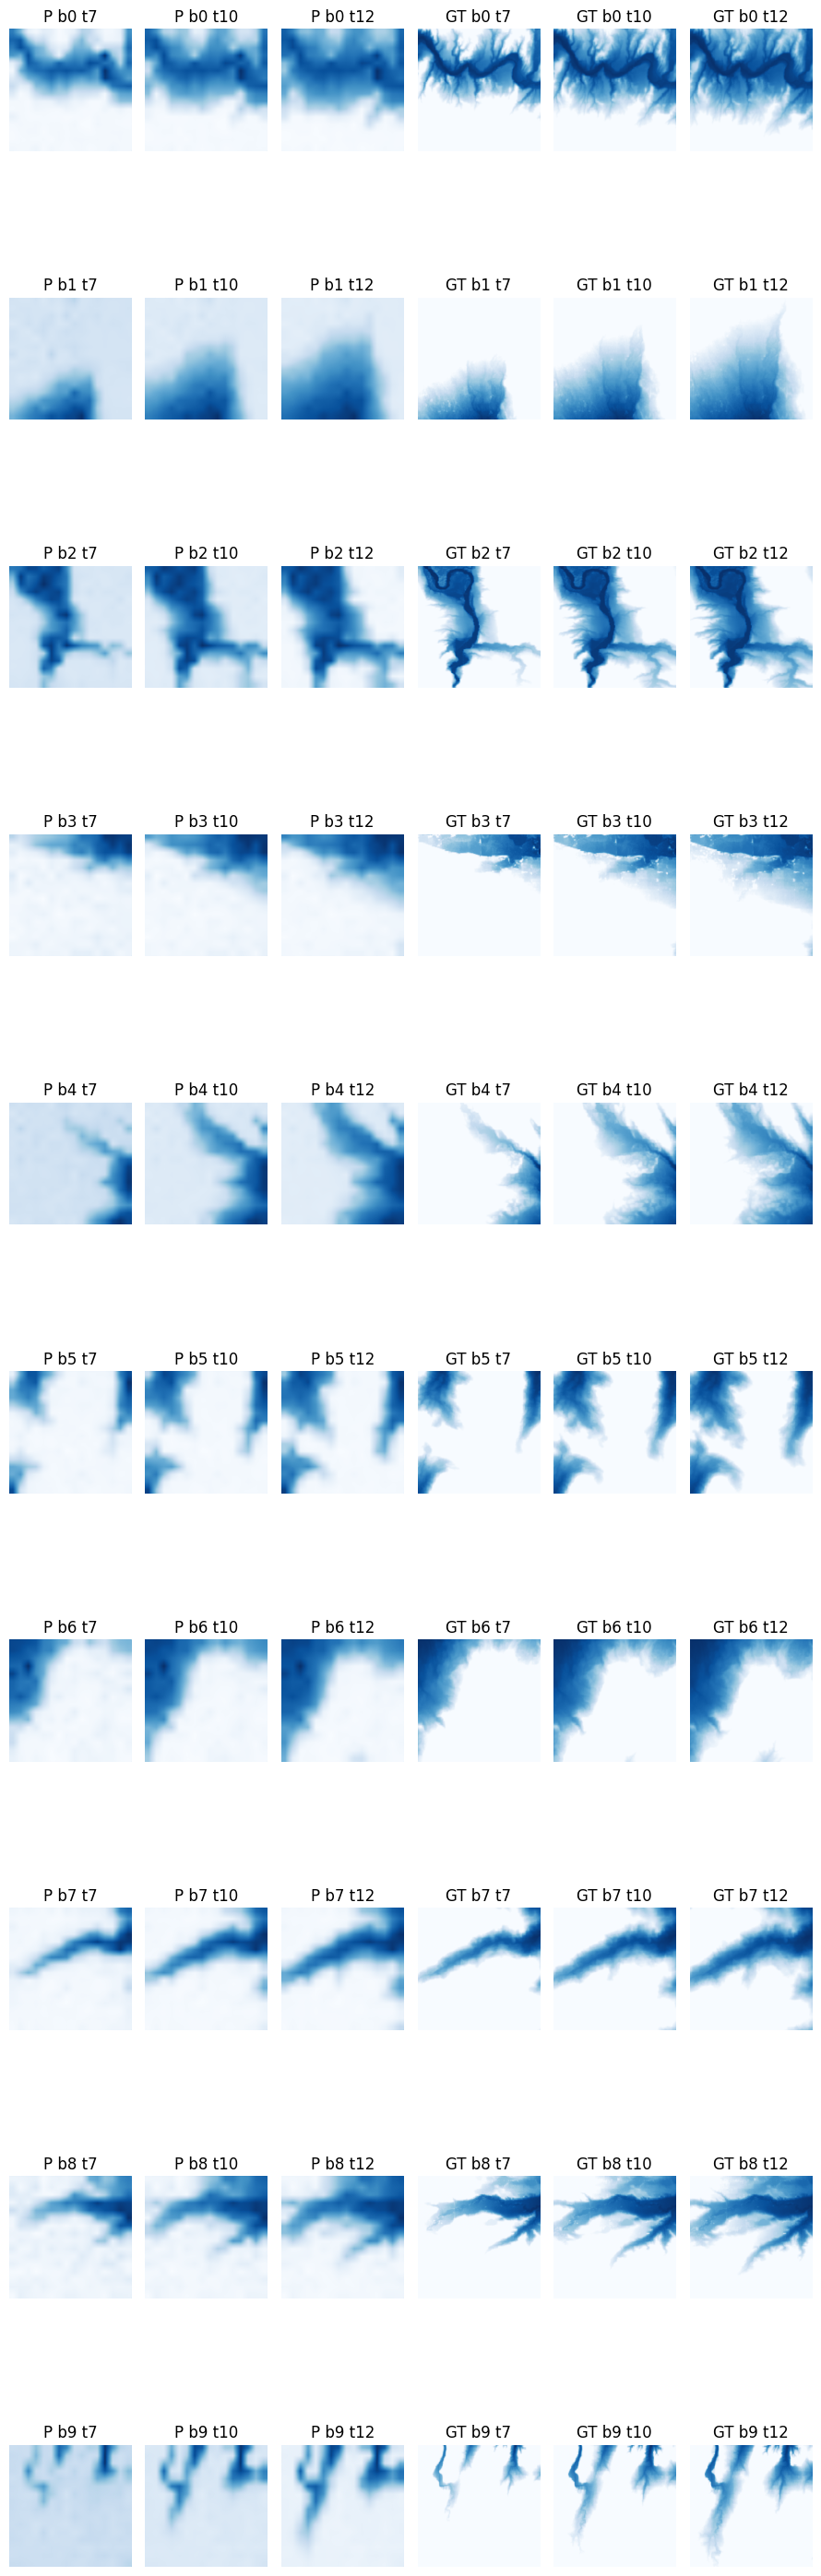

In [4]:
import matplotlib.pyplot as plt
import torch

# pred, gt: [B, C, T, H, W]
B, C, T, H, W = pred.shape

# Choose timestamps to visualize
timestamps = [7, 10, 12]   # <-- customize here
num_t = len(timestamps)

fig, axes = plt.subplots(B, num_t * 2, figsize=(num_t * 3, B * 3))

for b in range(B):
    for i, t in enumerate(timestamps):
        # Prediction
        ax_pred = axes[b, i]
        ax_pred.imshow(pred[b, 0, t].cpu(), cmap="Blues")
        ax_pred.set_title(f"P b{b} t{t}")
        ax_pred.axis("off")

        # Ground truth
        ax_gt = axes[b, i + num_t]
        ax_gt.imshow(flood_label[b, 0, t].cpu(), cmap="Blues")
        ax_gt.set_title(f"GT b{b} t{t}")
        ax_gt.axis("off")

plt.tight_layout()
plt.show()


# Video generation

In [17]:
import os
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

def save_video_from_sample_folders(root_dir, out_path="decoder_progress.mp4", fps=2):
    """
    root_dir: path to the folder containing epoch_*_step_* subfolders
    out_path: output video file
    fps: frames per second
    """

    # List all subfolders (epoch_XXX_step_XXXX)
    subfolders = [
        os.path.join(root_dir, d)
        for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ]

    # Sort lexicographically → epoch order
    subfolders = sorted(subfolders)

    video_frames = []
    cmap = plt.get_cmap("Blues")

    for folder in subfolders:
        frames = []

        for t in range(16):
            fname = os.path.join(folder, f"decoded_t{t:02d}.png")
            if not os.path.exists(fname):
                raise FileNotFoundError(f"Missing frame: {fname}")

            img = imageio.imread(fname)

            # Convert grayscale → float32
            if img.ndim == 3:
                # If already RGB, convert to grayscale first
                img = img.mean(axis=-1)

            img = img.astype(np.float32)

            # Normalize to [0,1]
            img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

            # Apply Blues colormap → RGBA
            img_color = cmap(img_norm)[..., :3]  # drop alpha

            # Convert to uint8 RGB
            img_uint8 = (img_color * 255).astype(np.uint8)

            frames.append(img_uint8)

        # Concatenate horizontally: [H, 16*W, 3]
        strip = np.concatenate(frames, axis=1)
        video_frames.append(strip)

    # Save video using ffmpeg backend
    with imageio.get_writer(out_path, fps=fps, codec='libx264', format='FFMPEG') as writer:
        for frame in video_frames:
            writer.append_data(frame)

    print(f"Saved progression video to {out_path}")


In [18]:
save_video_from_sample_folders(
    root_dir="../samples",
    out_path="decoder_progress.mp4",
    fps=1
)

[rawvideo @ 0x6d3d140] Stream #0: not enough frames to estimate rate; consider increasing probesize


Saved progression video to decoder_progress.mp4


# next state prediction

In [3]:
from app.vjepa_flood.utils import init_opt, init_video_model, load_checkpoint, load_pretrained

from app.vjepa_flood.flood_loader import init_data
import yaml
from app.vjepa_flood.transforms import GeoVideoTransformWithCrop
from src.datasets.geonpy_loader import make_geonpy_loader

In [4]:
# -----------------------------
# 1. Load model + checkpoint
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

patch_size = 16
tubelet_size = 2
max_num_frames = 16
crop_size = 256
in_chans = 22
B = 8

encoder, predictor = init_video_model(
    device=device,
    patch_size=patch_size,
    max_num_frames=max_num_frames,
    tubelet_size=tubelet_size,
    model_name="vit_base",
    crop_size=crop_size,
    pred_depth=24,
    pred_num_heads=16,
    pred_embed_dim=1024,
    meta_embed_dim=1,
    pred_is_frame_causal=True,
    in_chans=in_chans,
    uniform_power=True,
    use_activation_checkpointing=False,
    use_sdpa=True,
    use_rope=True,
    wide_silu=True,
    use_silu=False,
    use_pred_silu=False,

    #c=1
)

target_encoder = encoder  # same architecture
target_encoder = target_encoder.to(device)
predictor = predictor.to(device)

# Load pretrained encoder weights
# Load pretrained target encoder checkpoint
ckpt = torch.load("../logs/pretrain/16.8.vitb.256px.16f/latest.pt", map_location=device, weights_only=True)

pretrained_dict = ckpt["target_encoder"]

# Strip both "module." and "backbone."
clean_state = {}
for k, v in pretrained_dict.items():
    k = k.replace("module.", "")
    k = k.replace("backbone.", "")
    clean_state[k] = v

msg = target_encoder.load_state_dict(clean_state, strict=True)
print("Target encoder loaded with msg:", msg)



# Load trained predictor checkpoint
ckpt = torch.load("../logs/flood/4.8.vitb16-256px-16f/latest.pt", map_location=device, weights_only=True)
predictor_state = ckpt["predictor"]
# Remove "module." prefix if present
predictor_state = {k.replace("module.", ""): v for k, v in predictor_state.items()}
msg = predictor.load_state_dict(predictor_state, strict=True)
print("predictor loaded with msg:", msg)

predictor.eval()
#target_encoder.eval()

# -----------------------------
# 2. Load a sample clip
# -----------------------------
# Apply same transform as training
transform = GeoVideoTransformWithCrop(
    ratio=[0.75, 1.35],
    scale=[0.3, 1.0],
    crop_size=crop_size,
    motion_shift=False,
)
video_collator = torch.utils.data.default_collate

root = os.path.abspath("../../../../Dataset_collection/Colorado_data/v_jepa_data/16f_v2 (no aspect)/normalized")
(val_loader, val_sampler) = init_data(
        root_path="/home/jovyan/Sujet_speciale/Dataset_collection/Colorado_data/v_jepa_data/16f_v2 (no aspect)/normalized",
        transform=transform,   # same transform or a deterministic one
        batch_size=B,
        collator=video_collator,
        pin_mem=False,
        num_workers=0,
        world_size=1,
        rank=0,
        persistent_workers=False,
        dataset_fpcs=[16],
        num_clips=1,
        frame_skip=1,
        training=False,
    )

[INFO    ][2026-04-16 20:53:06][root                ][init_video_model         ] VisionTransformer(
  (patch_embed): PatchEmbed3D(
    (proj): Conv3d(22, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): RoPEAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, 

In [53]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [5]:
import torch

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.1f} MB")
print(f"Reserved:  {torch.cuda.memory_reserved()/1024**2:.1f} MB")


Allocated: 6251.6 MB
Reserved:  7830.0 MB


In [7]:
B = h.size(0)
T = max_num_frames  # 16

vals = torch.linspace(0.0, 0.5, steps=T, device=h.device)  # [16]
deltas = vals[1:] - vals[:-1]  # [15]

rainfall_intensities = deltas.view(1, T-1, 1).expand(B, -1, -1)
rainfall_intensities.shape

torch.Size([10, 15, 1])

In [7]:
T = 16

normalize_reps = False
tokens_per_frame = int((crop_size // patch_size) ** 2)

rainfall_intensities = torch.full((T, 1), 0.0, dtype=torch.float32, device="cuda")
rainfall_intensities = rainfall_intensities.view(1, T, 1).expand(B, -1, -1)
rainfall_intensities.shape

torch.Size([8, 16, 1])

In [30]:
rainfall_intensities.shape

torch.Size([8, 16, 1])

In [28]:
_h, _r = h[:, -tokens_per_frame:], rainfall_intensities[:, -1:]
z_tf = predictor(_h, _r)

/opt/conda/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


RuntimeError: The expanded size of the tensor (3855) must match the existing size (2056) at non-singleton dimension 3.  Target sizes: [8, 16, 3855, 3855].  Tensor sizes: [2056, 2056]

In [11]:
z_tf = z_tf.repeat(1, 16, 1)

In [12]:
with torch.inference_mode():
    pred = decoder(z_tf)

In [24]:
true_clip = clip[:, 0, -1][:, None, None, ...].repeat(1, 1, 16, 1, 1)

In [25]:
true_clip.shape

torch.Size([8, 1, 16, 256, 256])

In [18]:
pred.shape

torch.Size([8, 1, 16, 256, 256])

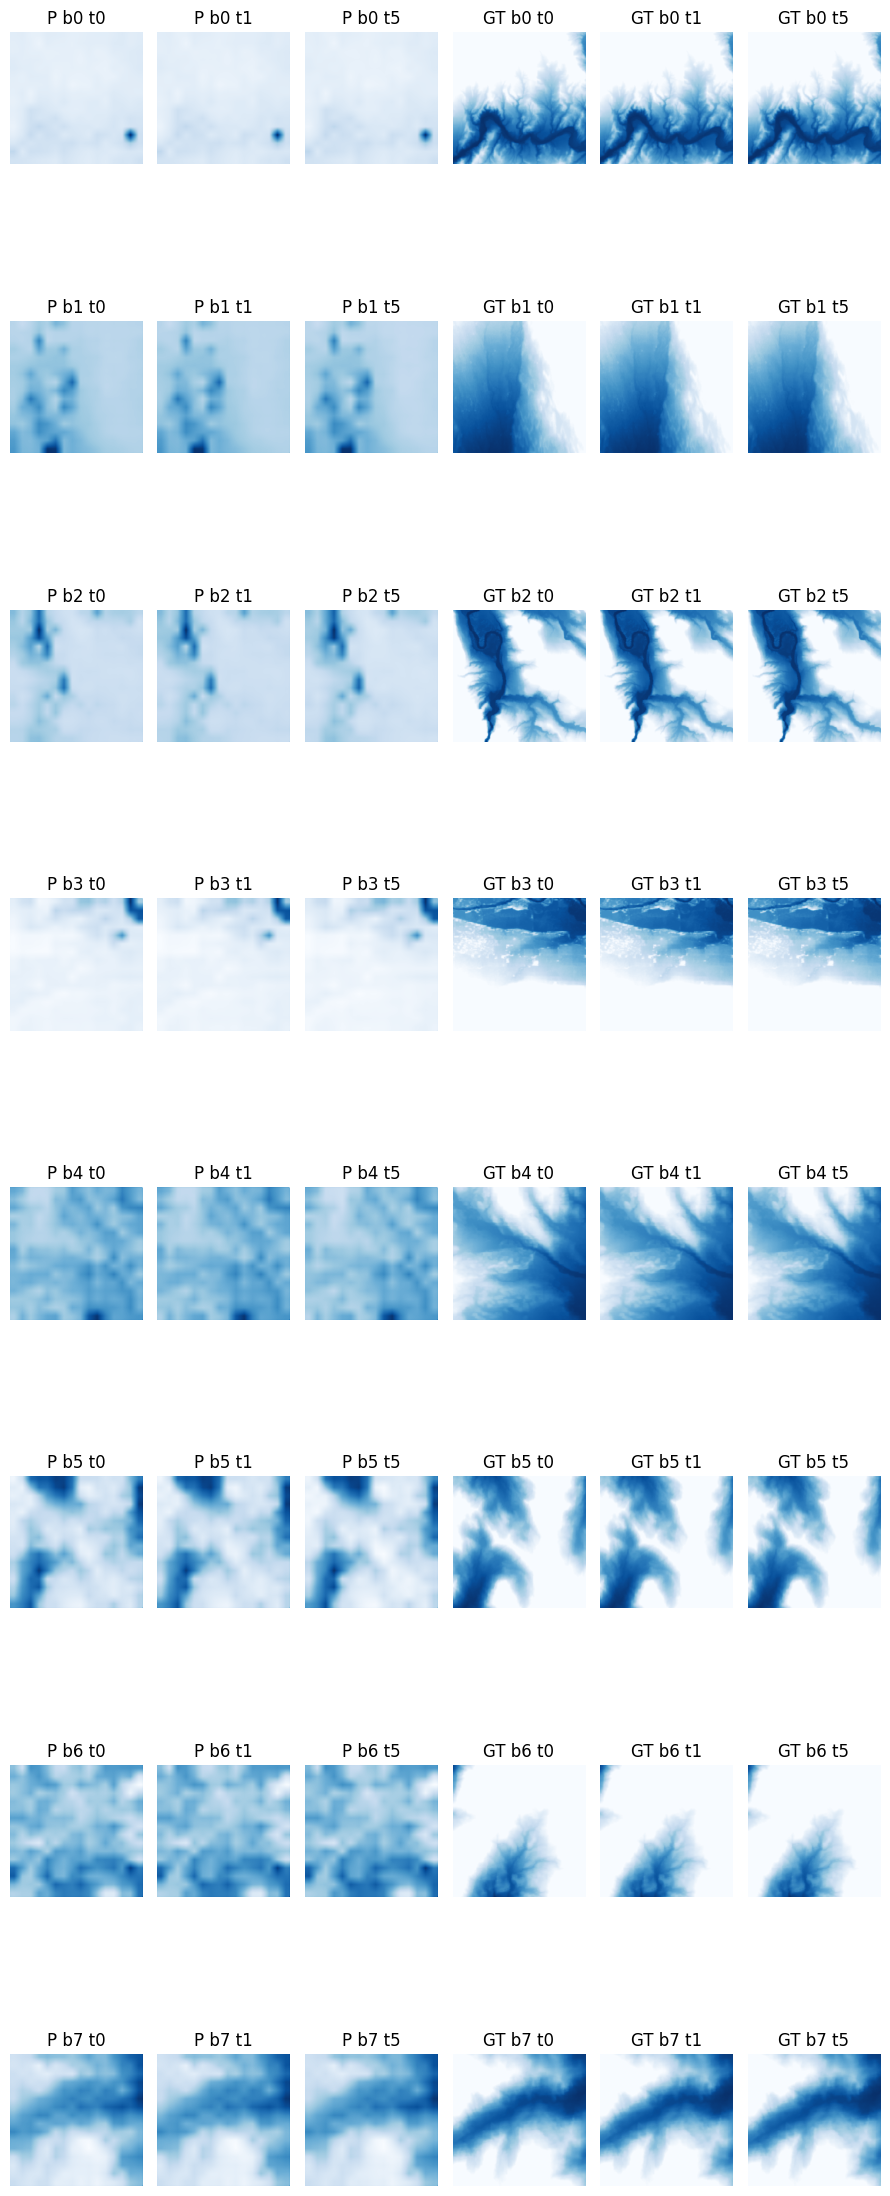

In [27]:
import matplotlib.pyplot as plt
import torch

# pred, gt: [B, C, T, H, W]
B, C, T, H, W = pred.shape

# Choose timestamps to visualize
timestamps = [0, 1, 5]   # <-- customize here
num_t = len(timestamps)

fig, axes = plt.subplots(B, num_t * 2, figsize=(num_t * 3, B * 3))

for b in range(B):
    for i, t in enumerate(timestamps):
        # Prediction
        ax_pred = axes[b, i]
        ax_pred.imshow(pred[b, 0, t].cpu(), cmap="Blues")
        ax_pred.set_title(f"P b{b} t{t}")
        ax_pred.axis("off")

        # Ground truth
        ax_gt = axes[b, i + num_t]
        ax_gt.imshow(true_clip[b, 0, t].cpu(), cmap="Blues")
        ax_gt.set_title(f"GT b{b} t{t}")
        ax_gt.axis("off")

plt.tight_layout()
plt.show()


In [13]:
def _step_predictor(_z, _r):
    with torch.no_grad():
        _z = predictor(_z, _r)
        if normalize_reps:
            _z = F.layer_norm(_z, (_z.size(-1),))
    return _z

# -- one step of predictor with teacher forcing
tokens_per_frame = 256
_z, _r = h[:, :-tokens_per_frame], rainfall_intensities
z_tf = _step_predictor(_z, _r)

/opt/conda/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


RuntimeError: The expanded size of the tensor (3855) must match the existing size (2056) at non-singleton dimension 3.  Target sizes: [10, 16, 3855, 3855].  Tensor sizes: [2056, 2056]

In [8]:
sample = next(iter(val_loader))
clip = sample[0].to("cuda") # [B, C, T, H, W]
rainfall_intensity = sample[1].to("cuda")
# -----------------------------
# 3. Forward through encoder
# -----------------------------
with torch.no_grad():
    # Duplicate frames for tubelet_size=2 (same as training)
    c = clip.permute(0, 2, 1, 3, 4)          # [B, T, C, H, W]
    c = c.flatten(0, 1).unsqueeze(2)         # [B*T, C, 1, H, W]
    c = c.repeat(1, 1, 2, 1, 1)              # [B*T, C, 2, H, W]

    h = target_encoder(c)                    # [B*T, N, D]
    h = h.view(B, max_num_frames, -1, h.size(-1)).flatten(1, 2)  # [1, N_total, D]

/opt/conda/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [31]:
normalize_reps = False
tokens_per_frame = int((crop_size // patch_size) ** 2)
def forward_predictions(z, rainfall_transitions, auto_steps=4):

    def _step_predictor(_z, _r):
        _z = predictor(_z, _r)
        if normalize_reps:
            _z = F.layer_norm(_z, (_z.size(-1),))
        return _z

    # -- one step of predictor with teacher forcing
    _z, _r = z[:, :-tokens_per_frame], rainfall_transitions
    z_tf = _step_predictor(_z, _r)

    # -- full auto-regressive rollouts of predictor
    _z = torch.cat([z[:, : tokens_per_frame], z_tf[:, : tokens_per_frame]], dim=1)
    for n in range(1, auto_steps):
        _r = rainfall_transitions[:, : n + 1] # [B, T-1, 1]
        _z_nxt = _step_predictor(_z, _r)[:, -tokens_per_frame:]
        _z = torch.cat([_z, _z_nxt], dim=1)
    z_ar = _z[:, tokens_per_frame:]

    return z_tf, z_ar

In [21]:
import torch.nn.functional as F
@torch.no_grad()
def rollout_future_floods(clip, rainfall_transitions, num_steps, normalize_reps=True):
    """
    clip: [B, C, T, H, W]          # input context frames (T = max_num_frames)
    rainfall_transitions: [B, T-1, 1]  # same as training (transitions within context)
    num_steps: int                 # how many future steps to roll out beyond T
    returns: list of [B, 1, H, W] flood maps for steps T, T+1, ..., T+num_steps-1
    """
    device = clip.device
    B, C, T, H, W = clip.shape

    # -----------------------------
    # 1. Encode context clip → h
    # -----------------------------
    c = clip.permute(0, 2, 1, 3, 4)      # [B, T, C, H, W]
    c = c.flatten(0, 1).unsqueeze(2)     # [B*T, C, 1, H, W]
    c = c.repeat(1, 1, 2, 1, 1)          # [B*T, C, 2, H, W]

    h = target_encoder(c)                # [B*T, N, D]
    h = h.view(B, T, -1, h.size(-1))     # [B, T, N, D]
    tokens_per_frame = h.size(2)
    h = h.flatten(1, 2)                  # [B, T*N, D]

    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))

    # -----------------------------
    # 2. Build initial z (context)
    # -----------------------------
    z = h.clone()                        # [B, T*N, D]
    all_floods = []

    # -----------------------------
    # 3. Rollout future steps
    # -----------------------------
    # We will extend rainfall with zeros for future steps (no known transitions)
    r_ctx = rainfall_transitions         # [B, T-1, 1]
    r_future = torch.zeros(B, num_steps, 1, device=device, dtype=r_ctx.dtype)
    r_full = torch.cat([r_ctx, r_future], dim=1)  # [B, T-1+num_steps, 1]

    for step in range(num_steps):
        # use transitions up to current step (same pattern as training loop)
        r_used = r_full[:, : (T - 1 + step) + 1]   # [B, T-1+step+1, 1]

        # predictor takes full history z and rainfall transitions
        z = predictor(z, r_used)                   # [B, (T+step)*N, D]
        if normalize_reps:
            z = F.layer_norm(z, (z.size(-1),))

        # take last frame tokens = predicted latent for time T+step
        z_next = z[:, -tokens_per_frame:]         # [B, N, D]

        # decode to flood map
        flood_next = decoder(z_next)              # e.g. [B, 1, H, W] or [B, 1, 1, H, W]
        all_floods.append(flood_next)

        # append predicted frame tokens to history for next rollout step
        z = torch.cat([z, z_next], dim=1)         # [B, (T+step+1)*N, D]

    return all_floods  # list length = num_steps


In [67]:
rainfall_intensities = torch.full((16, 1), 0.033, dtype=torch.float32)
#rainfall_intensities = rainfall_intensities[::1]
#rainfall_intensities = rainfall_intensities[1:, :] - rainfall_intensities[:-1, :]

In [68]:
rainfall_intensities.shape

torch.Size([16, 1])

In [22]:
num_steps = 4  # predict 4 future frames

sample = next(iter(val_loader))
clip = sample[0].to("cuda") # [B, C, T, H, W]
rainfall_intensity = sample[1].to("cuda")

future_floods = rollout_future_floods(clip, rainfall_intensity, num_steps)

# future_floods[0] → flood at T
# future_floods[1] → flood at T+1
# ...


RuntimeError: The expanded size of the tensor (4112) must match the existing size (2056) at non-singleton dimension 3.  Target sizes: [10, 16, 4112, 4112].  Tensor sizes: [2056, 2056]

In [ ]:
import matplotlib.pyplot as plt
import torch

# pred, gt: [B, C, T, H, W]
B, C, T, H, W = pred.shape

# Choose timestamps to visualize
timestamps = [7, 8, 15]   # <-- customize here
num_t = len(timestamps)

fig, axes = plt.subplots(B, num_t * 2, figsize=(num_t * 3, B * 3))

for b in range(B):
    for i, t in enumerate(timestamps):
        # Prediction
        ax_pred = axes[b, i]
        ax_pred.imshow(pred[b, 0, t].cpu(), cmap="Blues")
        ax_pred.set_title(f"P b{b} t{t}")
        ax_pred.axis("off")

        # Ground truth
        ax_gt = axes[b, i + num_t]
        ax_gt.imshow(flood_label[b, 0, t].cpu(), cmap="Blues")
        ax_gt.set_title(f"GT b{b} t{t}")
        ax_gt.axis("off")

plt.tight_layout()
plt.show()
